# Camp 2 — Modeling & Access
### Data GOLD Field Notes · Series Demo 03

Six terms, three sections: **Data Modeling** on its own, **OLTP vs. OLAP** as a comparison, and **Data Partitioning vs. Data Sharding** as a comparison, closing with **Indexing** measured on a 100,000-row table.

Each section is self-contained — run top to bottom, or jump to the term you're studying.


## Setup

In [1]:
import sqlite3
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

random.seed(42)


## Section A — Data Modeling

Designing how data is structured and how its pieces relate. Below: a small entity relationship model — customers place orders, orders contain items, items reference products — then the tables and a query that walks all four hops.


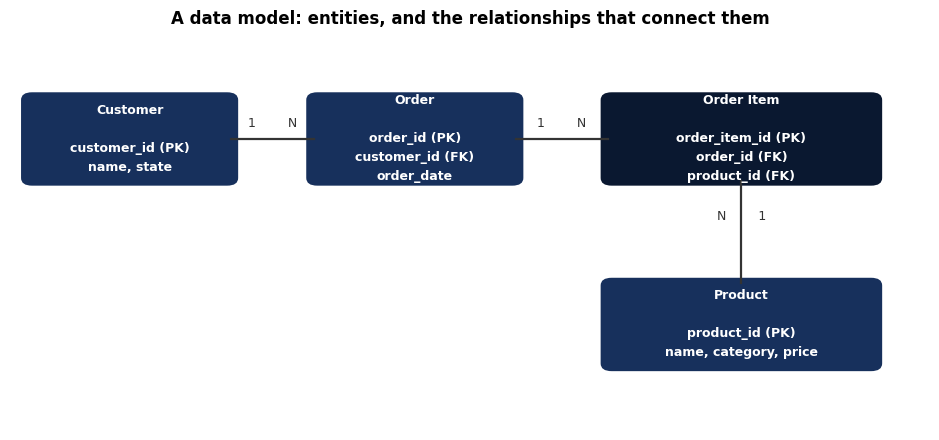

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")

def box(x, y, w, h, text, facecolor, textcolor="white", fontsize=9):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        facecolor=facecolor, edgecolor="none"
    ))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            color=textcolor, fontsize=fontsize, fontweight="bold", linespacing=1.6)

def rel(x1, y1, x2, y2, label, color="#333333"):
    ax.plot([x1, x2], [y1, y2], color=color, lw=1.6)
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.18, label, fontsize=9, ha="center", color=color)

box(0.2, 3.9, 2.2, 1.3, "Customer\n\ncustomer_id (PK)\nname, state", "#17305C")
box(3.3, 3.9, 2.2, 1.3, "Order\n\norder_id (PK)\ncustomer_id (FK)\norder_date", "#17305C")
box(6.5, 3.9, 2.9, 1.3, "Order Item\n\norder_item_id (PK)\norder_id (FK)\nproduct_id (FK)", "#0A1830")
box(6.5, 1.0, 2.9, 1.3, "Product\n\nproduct_id (PK)\nname, category, price", "#17305C")

rel(2.4, 4.55, 3.3, 4.55, "1        N")
rel(5.5, 4.55, 6.5, 4.55, "1        N")
rel(7.95, 3.9, 7.95, 2.3, "N        1")

ax.set_title("A data model: entities, and the relationships that connect them",
             fontsize=12, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()


In [5]:
model_conn = sqlite3.connect(":memory:")
model_conn.executescript("""
CREATE TABLE customers   (customer_id INTEGER, name TEXT, state TEXT);
CREATE TABLE orders      (order_id INTEGER, customer_id INTEGER, order_date TEXT);
CREATE TABLE order_items (order_item_id INTEGER, order_id INTEGER, product_id INTEGER, quantity INTEGER);
CREATE TABLE products    (product_id INTEGER, name TEXT, category TEXT, price REAL);
""")

customers = [(1, "Alicia Chen", "NC"), (2, "Bob Diaz", "SC"), (3, "Marcus Lee", "VA")]
orders = [(1, 1, "2026-01-10"), (2, 2, "2026-01-11"), (3, 1, "2026-01-15")]
products = [(1, "CRM Suite", "Software", 4200.00), (2, "Laptop Dock", "Hardware", 350.00)]
order_items = [(1, 1, 1, 1), (2, 1, 2, 2), (3, 2, 2, 1), (4, 3, 1, 1)]

model_conn.executemany("INSERT INTO customers VALUES (?,?,?)", customers)
model_conn.executemany("INSERT INTO orders VALUES (?,?,?)", orders)
model_conn.executemany("INSERT INTO products VALUES (?,?,?,?)", products)
model_conn.executemany("INSERT INTO order_items VALUES (?,?,?,?)", order_items)
model_conn.commit()

print("Walking all four hops: revenue by customer, by product category")
pd.read_sql("""
    SELECT c.name AS customer, p.category, SUM(p.price * oi.quantity) AS revenue
    FROM customers c
    JOIN orders o       ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN products p     ON oi.product_id = p.product_id
    GROUP BY c.name, p.category
    ORDER BY revenue DESC
""", model_conn)


Walking all four hops: revenue by customer, by product category


,customer,category,revenue
0,Alicia Chen,Software,8400.0
1,Alicia Chen,Hardware,700.0
2,Bob Diaz,Hardware,350.0


## Section B — OLTP vs. OLAP

Same underlying business, two different jobs. OLTP handles one transaction at a time, fast. OLAP aggregates across everything, at a completely different scale.


### 2. OLTP — one transaction, immediately readable


In [7]:
oltp_conn = sqlite3.connect(":memory:")
oltp_conn.execute("CREATE TABLE orders (order_id INTEGER PRIMARY KEY, customer_id INTEGER, status TEXT, amount REAL)")
oltp_conn.commit()

def place_order(conn, customer_id, amount):
    start = time.perf_counter()
    conn.execute("INSERT INTO orders (customer_id, status, amount) VALUES (?, 'pending', ?)", (customer_id, amount))
    conn.commit()
    order_id = conn.execute("SELECT last_insert_rowid()").fetchone()[0]
    row = conn.execute("SELECT * FROM orders WHERE order_id = ?", (order_id,)).fetchone()
    elapsed_ms = (time.perf_counter() - start) * 1000
    return row, elapsed_ms

row, elapsed_ms = place_order(oltp_conn, customer_id=1, amount=249.00)
print(f"OLTP — single order written and immediately read back: {row}")
print(f"Handled in {elapsed_ms:.3f} ms — this is the workload checkout depends on.")


OLTP — single order written and immediately read back: (1, 1, 'pending', 249.0)
Handled in 0.169 ms — this is the workload checkout depends on.


### 3. OLAP — aggregating everything at once


In [9]:
olap_conn = sqlite3.connect(":memory:")
olap_conn.execute("CREATE TABLE orders (order_id INTEGER, order_date TEXT, amount REAL)")

bulk_orders = [
    (i, f"2026-{random.randint(1,6):02d}-{random.randint(1,28):02d}", round(random.uniform(20, 500), 2))
    for i in range(1, 20001)
]
olap_conn.executemany("INSERT INTO orders VALUES (?,?,?)", bulk_orders)
olap_conn.commit()

start = time.perf_counter()
monthly = pd.read_sql("""
    SELECT substr(order_date,1,7) AS month, COUNT(*) AS orders, ROUND(SUM(amount),2) AS revenue
    FROM orders GROUP BY month ORDER BY month
""", olap_conn)
elapsed_ms = (time.perf_counter() - start) * 1000

print(f"OLAP — {len(bulk_orders):,} rows aggregated into a monthly summary in {elapsed_ms:.2f} ms")
print("Same kind of database engine, a completely different optimization target.\n")
monthly


OLAP — 20,000 rows aggregated into a monthly summary in 18.31 ms
Same kind of database engine, a completely different optimization target.



,month,orders,revenue
0,2026-01,3332,864291.02
1,2026-02,3287,859481.72
2,2026-03,3343,871742.76
3,2026-04,3465,892569.07
4,2026-05,3255,849095.23
5,2026-06,3318,852728.15


## Section C — Data Partitioning vs. Data Sharding

Same idea (too much data in one place), two different fixes. Partitioning splits data into segments within one system. Sharding spreads it across separate systems entirely.


### 4. Data Partitioning — segments within one system


In [11]:
part_conn = sqlite3.connect(":memory:")
quarters = ["2026_Q1", "2026_Q2", "2026_Q3", "2026_Q4"]
for q in quarters:
    part_conn.execute(f"CREATE TABLE orders_{q} (order_id INTEGER, order_date TEXT, amount REAL)")

for i in range(1, 4001):
    month = random.randint(1, 12)
    quarter = f"2026_Q{((month - 1) // 3) + 1}"
    date = f"2026-{month:02d}-{random.randint(1, 28):02d}"
    amount = round(random.uniform(20, 500), 2)
    part_conn.execute(f"INSERT INTO orders_{quarter} VALUES (?,?,?)", (i, date, amount))
part_conn.commit()

def revenue_for_quarter(conn, quarter):
    return conn.execute(f"SELECT COUNT(*), ROUND(SUM(amount),2) FROM orders_{quarter}").fetchone()

count, revenue = revenue_for_quarter(part_conn, "2026_Q2")
print(f"Asked for Q2 only: {count} rows scanned, ${revenue} in revenue.")
print("The other three partitions (Q1, Q3, Q4) were never touched.")


Asked for Q2 only: 988 rows scanned, $265762.17 in revenue.
The other three partitions (Q1, Q3, Q4) were never touched.


### 5. Data Sharding — spread across separate systems


In [13]:
NUM_SHARDS = 2
shards = [sqlite3.connect(":memory:") for _ in range(NUM_SHARDS)]
for shard in shards:
    shard.execute("CREATE TABLE customers (customer_id INTEGER, name TEXT, state TEXT)")

def shard_for(customer_id):
    return customer_id % NUM_SHARDS

customers_data = [(i, f"Customer {i}", random.choice(["NC", "SC", "VA", "GA"])) for i in range(1, 11)]
for cust in customers_data:
    shards[shard_for(cust[0])].execute("INSERT INTO customers VALUES (?,?,?)", cust)
for shard in shards:
    shard.commit()

print("Each customer routed to a shard (a separate database connection) by customer_id:")
for i, shard in enumerate(shards):
    ids = [r[0] for r in shard.execute("SELECT customer_id FROM customers").fetchall()]
    print(f"  shard {i}: customers {ids}")

def get_customer(customer_id):
    shard = shards[shard_for(customer_id)]
    return shard.execute("SELECT * FROM customers WHERE customer_id = ?", (customer_id,)).fetchone()

print("\nLooking up customer 7 — routed straight to its shard, the other shard is never queried:")
print(get_customer(7))


Each customer routed to a shard (a separate database connection) by customer_id:
  shard 0: customers [2, 4, 6, 8, 10]
  shard 1: customers [1, 3, 5, 7, 9]

Looking up customer 7 — routed straight to its shard, the other shard is never queried:
(7, 'Customer 7', 'SC')


## Section D — Indexing

Building a lookup structure that lets the database jump straight to the answer. Below: the same lookup on a 100,000-row table, timed before and after adding an index.


In [15]:
idx_conn = sqlite3.connect(":memory:")
idx_conn.execute("CREATE TABLE big_orders (order_id INTEGER, customer_id INTEGER, amount REAL)")

big_data = [(i, random.randint(1, 50000), round(random.uniform(5, 999), 2)) for i in range(1, 100001)]
idx_conn.executemany("INSERT INTO big_orders VALUES (?,?,?)", big_data)
idx_conn.commit()

target_customer = 12345
query = "SELECT * FROM big_orders WHERE customer_id = ?"

plan_before = idx_conn.execute(f"EXPLAIN QUERY PLAN {query}", (target_customer,)).fetchall()
start = time.perf_counter()
idx_conn.execute(query, (target_customer,)).fetchall()
no_index_ms = (time.perf_counter() - start) * 1000

idx_conn.execute("CREATE INDEX idx_customer_id ON big_orders(customer_id)")
idx_conn.commit()

plan_after = idx_conn.execute(f"EXPLAIN QUERY PLAN {query}", (target_customer,)).fetchall()
start = time.perf_counter()
idx_conn.execute(query, (target_customer,)).fetchall()
with_index_ms = (time.perf_counter() - start) * 1000

print(f"Without an index — plan: {plan_before[0][3]}")
print(f"  {no_index_ms:.3f} ms\n")
print(f"With an index    — plan: {plan_after[0][3]}")
print(f"  {with_index_ms:.3f} ms\n")
print(f"Speedup: {no_index_ms / with_index_ms:.1f}x faster, same 100,000-row table, same query.")


Without an index — plan: SCAN big_orders
  12.703 ms

With an index    — plan: SEARCH big_orders USING INDEX idx_customer_id (customer_id=?)
  0.213 ms

Speedup: 59.6x faster, same 100,000-row table, same query.


---
### Recap

| Term | The one-line test |
|---|---|
| **Data Modeling** | Are the entities and their relationships explicitly defined? |
| **OLTP** | Is it optimized for one fast transaction at a time? |
| **OLAP** | Is it optimized for aggregating across everything at once? |
| **Data Partitioning** | Are segments split within one system so queries touch less data? |
| **Data Sharding** | Is data spread across separate systems entirely, with a router deciding where to look? |
| **Indexing** | Is there a lookup structure that skips the full scan? |

**Data GOLD** — Turning data complexity into business GOLD.
